<a href="https://colab.research.google.com/github/riskoptima/blog/blob/master/VIX_SPIKE_DETECTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VIX SPIKE PREDICTION - FIXED THRESHOLD

Spike Definition: VIX > 20.0 TOMORROW
Prediction Threshold: 0.120 (FIXED)

Training: First 5 months of 2025 (Jan 1 - May 31)
Testing: Remainder of 2025 (June 1 onwards)

Features: 8 (NO VIX - NO CHEATING)

Dataset: 1254 days (2020-12-01 to 2025-11-26)

Total days with VIX > 20.0 tomorrow: 469 / 1253 (37.43%)

STEP 1: SPLIT DATA

Train: 102 days
Test: 124 days

STEP 2: CREATE FEATURES
✓ Market features: 5

STEP 3: GENERATE HESTON FEATURES

Generating for TRAIN...
✓ Train: 102 days in 0.2s

Generating for TEST...
✓ Test: 124 days in 0.2s

STEP 4: PREPARE DATA

Train: 102 days (2025-01-02 to 2025-05-30)
  Spikes (VIX > 20.0 next day): 46 (45.10%)

Test: 124 days (2025-06-02 to 2025-11-25)
  Spikes (VIX > 20.0 next day): 16 (12.90%)

Features: 8 total

STEP 5: TRAIN MODEL
✓ Model trained

STEP 6: MAKE PREDICTIONS (FIXED THRESHOLD)

Using FIXED threshold: 0.120
Predictions made for 124 test days

PERFORMANCE METRICS

Spike Definition: VIX > 20.0 TOMOR

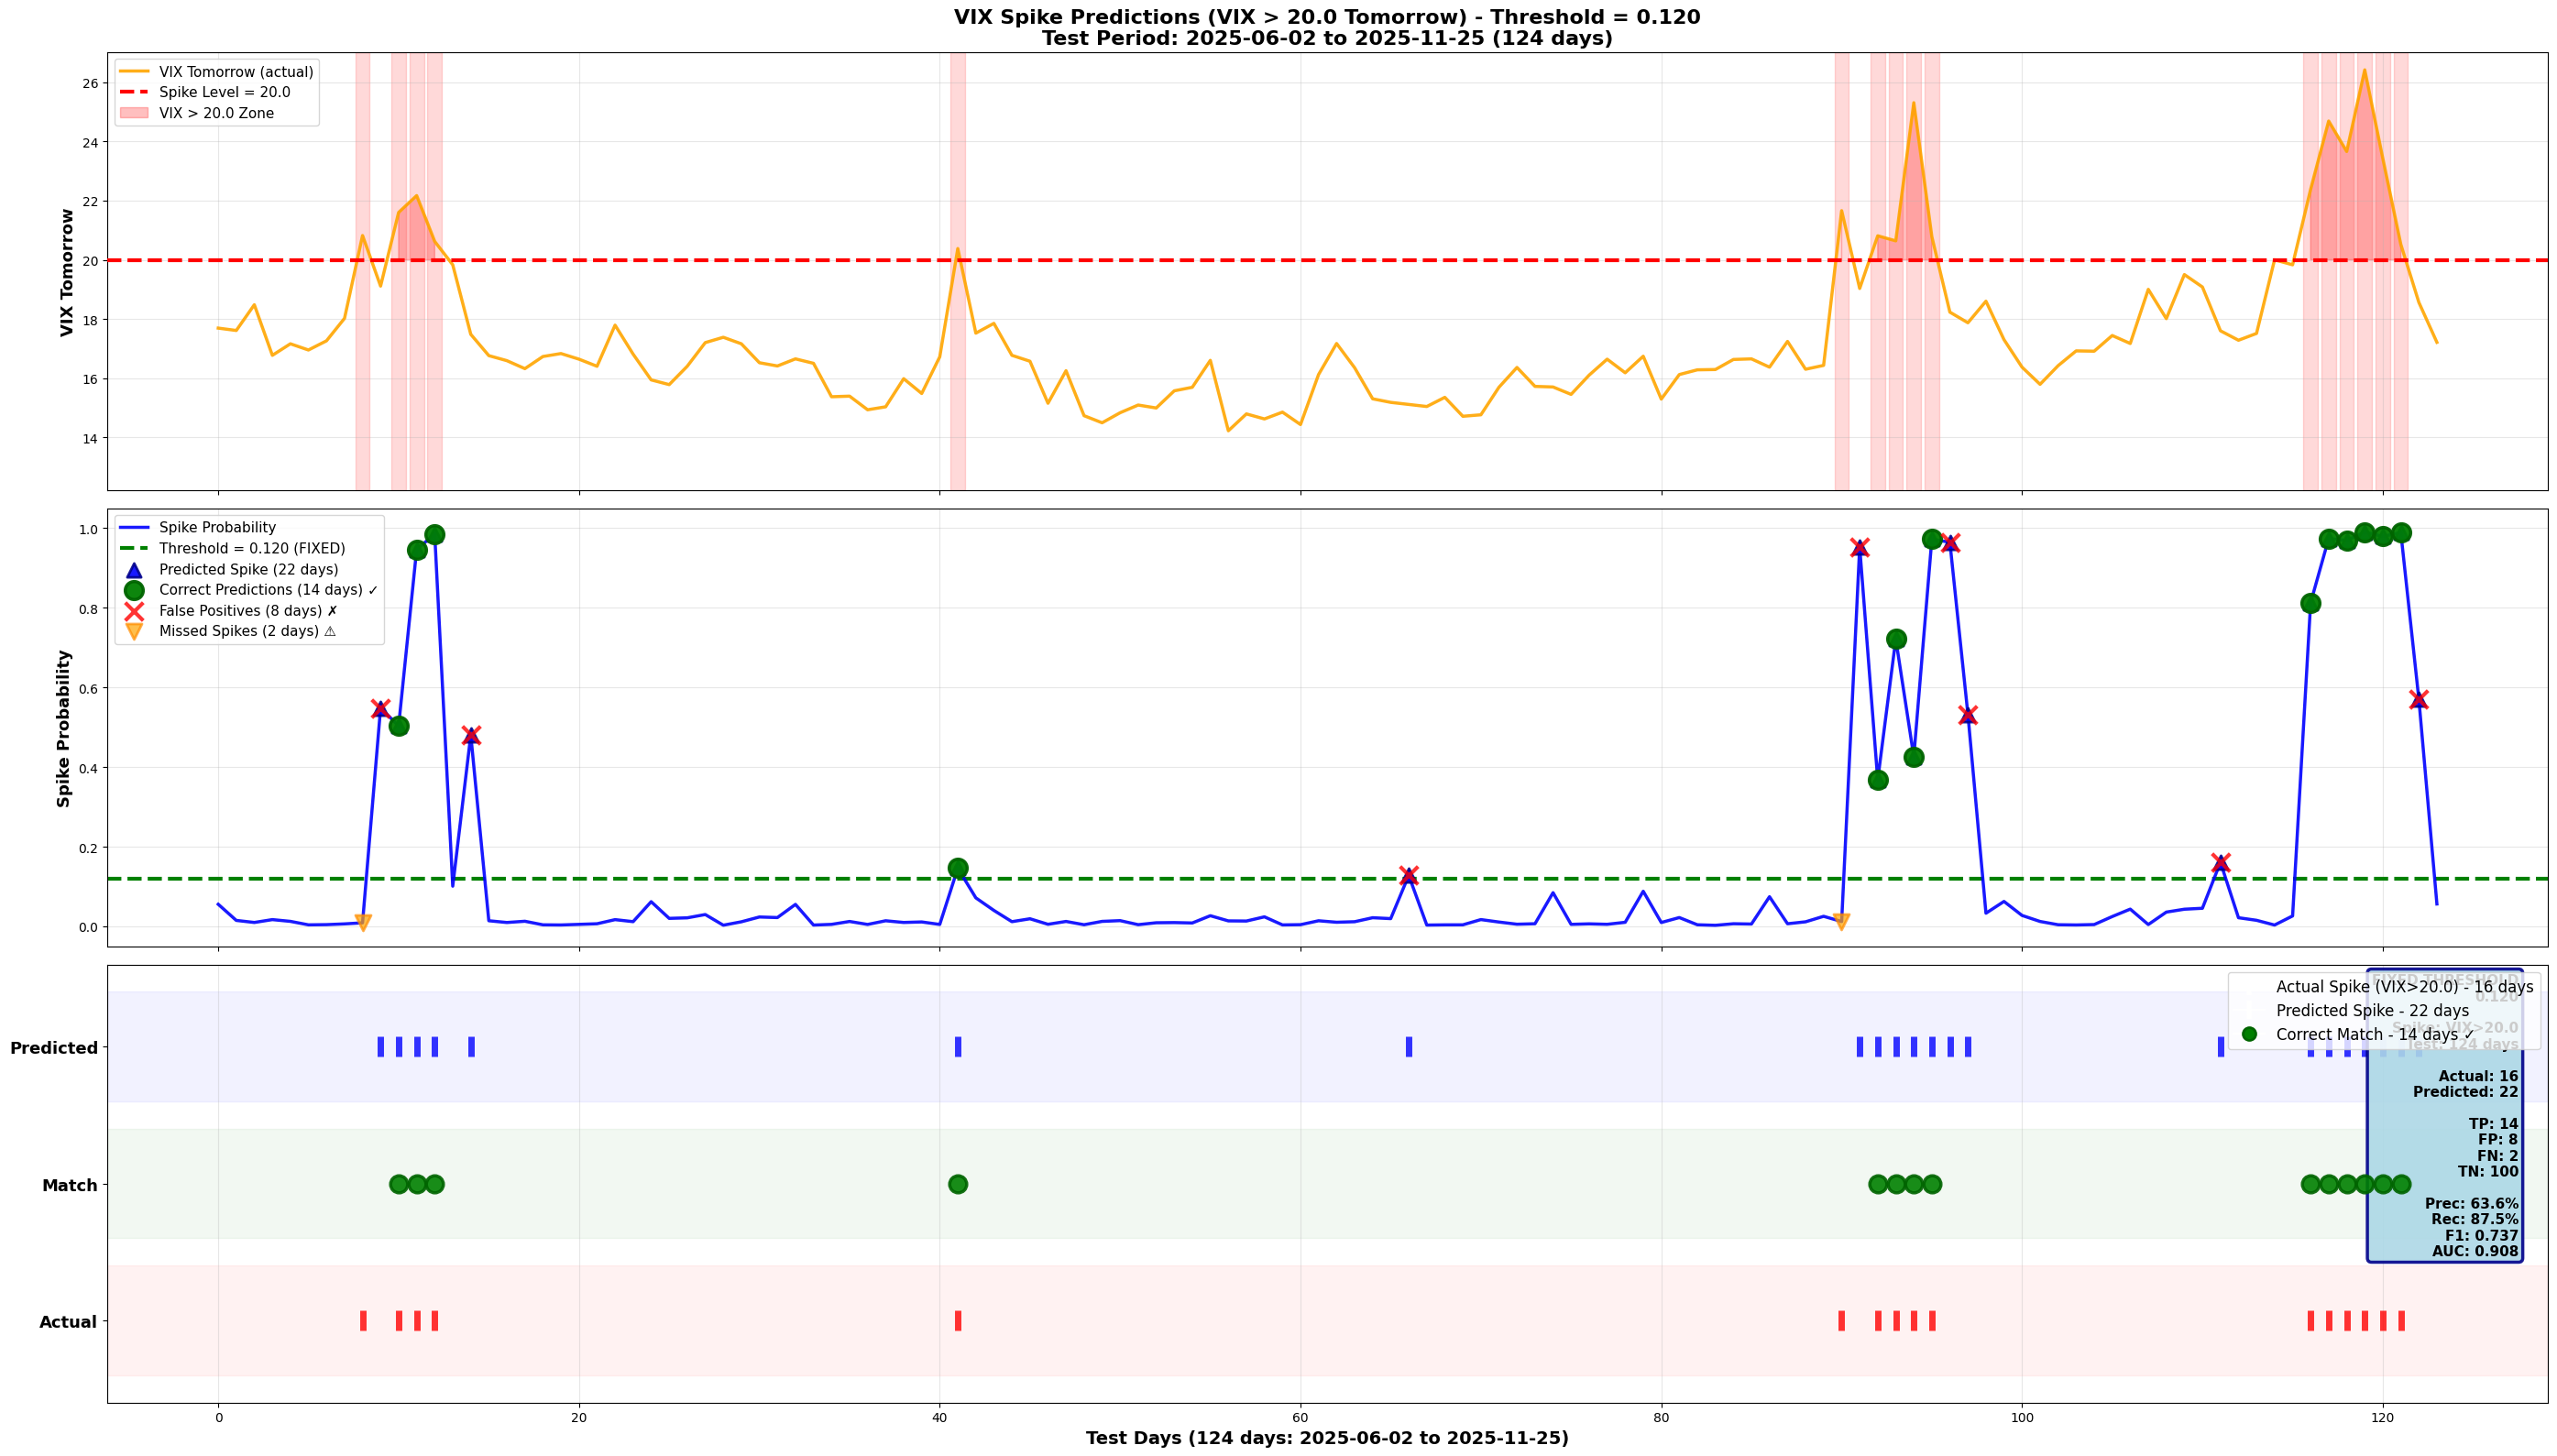

In [50]:
"""
VIX Spike Prediction - FIXED THRESHOLD
Spike Definition: VIX > 20 TOMORROW
Fixed Threshold: 0.13(NO OPTIMIZATION)
Training: First 5 months of 2025
Testing: Remainder of 2025
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

SPIKE_LEVEL = 20.0  # VIX spike = VIX > 20
PREDICTION_THRESHOLD = 0.12  # FIXED - NO OPTIMIZATION
N_PATHS = 2000
HESTON_WINDOW = 252

print("="*80)
print("VIX SPIKE PREDICTION - FIXED THRESHOLD")
print("="*80)
print(f"\nSpike Definition: VIX > {SPIKE_LEVEL} TOMORROW")
print(f"Prediction Threshold: {PREDICTION_THRESHOLD:.3f} (FIXED)")
print(f"\nTraining: First 5 months of 2025 (Jan 1 - May 31)")
print(f"Testing: Remainder of 2025 (June 1 onwards)")
print(f"\nFeatures: 8 (NO VIX - NO CHEATING)")

# ============================================================================
# LOAD DATA
# ============================================================================

df = pd.read_csv('/content/SPX_VIX_DATA.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df_clean = df.dropna(subset=['LR_SPX', 'LR_SPX_ IV', 'LR_VIX', 'LR_VIX_IV']).copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nDataset: {len(df_clean)} days ({df_clean['Date'].iloc[0].date()} to {df_clean['Date'].iloc[-1].date()})")

# ============================================================================
# CREATE TARGET: VIX > 20 TOMORROW
# ============================================================================

df_clean['VIX_Next'] = df_clean['VIX'].shift(-1)
df_clean['VIX_Spike_Next'] = (df_clean['VIX_Next'] > SPIKE_LEVEL).astype(int)
df_clean = df_clean[:-1].copy()

spike_count = df_clean['VIX_Spike_Next'].sum()
print(f"\nTotal days with VIX > {SPIKE_LEVEL} tomorrow: {spike_count} / {len(df_clean)} ({spike_count/len(df_clean)*100:.2f}%)")

# ============================================================================
# SPLIT DATA - 2025 BASED
# ============================================================================

print(f"\n{'='*80}")
print("STEP 1: SPLIT DATA")
print("="*80)

train_start = pd.Timestamp('2025-01-01')
train_end = pd.Timestamp('2025-05-31')
test_start = pd.Timestamp('2025-06-01')

mask_2025 = df_clean['Date'].dt.year == 2025

if mask_2025.sum() == 0:
    print("\n⚠️ No 2025 data. Using alternative split.")
    train_days = min(100, int(len(df_clean) * 0.5))
    train_indices = df_clean.index[:train_days]
    test_indices = df_clean.index[train_days:]
else:
    df_2025 = df_clean[mask_2025]
    train_mask = (df_2025['Date'] >= train_start) & (df_2025['Date'] <= train_end)
    test_mask = df_2025['Date'] >= test_start
    train_indices = df_2025[train_mask].index
    test_indices = df_2025[test_mask].index

print(f"\nTrain: {len(train_indices)} days")
print(f"Test: {len(test_indices)} days")

# ============================================================================
# CREATE MARKET FEATURES (NO VIX)
# ============================================================================

print(f"\n{'='*80}")
print("STEP 2: CREATE FEATURES")
print("="*80)

df_clean['lr_vix_ma5'] = df_clean['LR_VIX'].rolling(5).mean()
df_clean['spx_down_5d'] = (df_clean['LR_SPX'] < 0).rolling(5).sum()
df_clean['lr_spx'] = df_clean['LR_SPX']
df_clean['lr_spx_ma5'] = df_clean['LR_SPX'].rolling(5).mean()
df_clean['spx_iv_chg'] = df_clean['SPX_ IV'].diff(1)

market_features = ['lr_vix_ma5', 'spx_down_5d', 'lr_spx', 'lr_spx_ma5', 'spx_iv_chg']
print(f"✓ Market features: {len(market_features)}")

# ============================================================================
# HESTON FUNCTIONS
# ============================================================================

def estimate_heston_params(df_hist):
    lr_S = df_hist['LR_SPX'].values
    lr_VS = df_hist['LR_SPX_ IV'].values
    lr_X = df_hist['LR_VIX'].values
    lr_VX = df_hist['LR_VIX_IV'].values

    VS = df_hist['SPX_ IV'].values
    VX = df_hist['VIX_IV'].values
    X = df_hist['VIX'].values

    corr_matrix = np.corrcoef(np.column_stack([lr_S, lr_VS, lr_X, lr_VX]).T)

    VS_mean = np.mean(VS)
    kappa_VS = -np.sum(np.diff(VS) * (VS[:-1] - VS_mean)) / (np.sum((VS[:-1] - VS_mean)**2) + 1e-10)

    X_mean = np.mean(X)
    kappa_X = -np.sum(np.diff(X) * (X[:-1] - X_mean)) / (np.sum((X[:-1] - X_mean)**2) + 1e-10)

    VX_mean = np.mean(VX)
    kappa_VX = -np.sum(np.diff(VX) * (VX[:-1] - VX_mean)) / (np.sum((VX[:-1] - VX_mean)**2) + 1e-10)

    params = {
        'mu_S': np.mean(lr_S) * 252,
        'kappa_VS': max(kappa_VS * 252, 0.1),
        'theta_VS': VS_mean,
        'sigma_VS': np.std(lr_VS) * np.sqrt(252),
        'kappa_X': max(kappa_X * 252, 0.1),
        'theta_X': X_mean,
        'kappa_VX': max(kappa_VX * 252, 0.1),
        'theta_VX': VX_mean,
        'sigma_VX': np.std(lr_VX) * np.sqrt(252)
    }

    Sigma = np.array([
        [1.0, corr_matrix[0,1], corr_matrix[0,2], corr_matrix[0,3]],
        [corr_matrix[0,1], 1.0, corr_matrix[1,2], corr_matrix[1,3]],
        [corr_matrix[0,2], corr_matrix[1,2], 1.0, corr_matrix[2,3]],
        [corr_matrix[0,3], corr_matrix[1,3], corr_matrix[2,3], 1.0]
    ])

    eig = np.linalg.eigvals(Sigma)
    if np.min(eig) <= 1e-10:
        eps = abs(np.min(eig)) + 0.01
        Sigma = Sigma + np.eye(4) * eps
        Sigma = np.diag(1/np.sqrt(np.diag(Sigma))) @ Sigma @ np.diag(1/np.sqrt(np.diag(Sigma)))

    L = np.linalg.cholesky(Sigma)
    return params, L


def simulate_heston_1day(S0, VS0, X0, VX0, params, L, n_paths=2000):
    dt = 1/252
    eps = 1e-8

    Z = np.random.standard_normal((n_paths, 4))
    dW = (L @ Z.T).T * np.sqrt(dt)

    VS0 = max(VS0, eps)
    VX0 = max(VX0, eps)

    log_S_next = np.log(S0) + (params['mu_S'] - 0.5*VS0)*dt + np.sqrt(VS0)*dW[:, 0]
    S_next = np.exp(log_S_next)

    X_next = X0 + params['kappa_X']*(params['theta_X'] - X0)*dt + np.sqrt(VX0)*X0*dW[:, 2]
    X_next = np.maximum(X_next, eps)

    return S_next, X_next


def extract_heston_features(S0, VS0, X0, VX0, params, L):
    S_sim, X_sim = simulate_heston_1day(S0, VS0, X0, VX0, params, L, n_paths=N_PATHS)
    vix_pct_change_sim = (X_sim - X0) / X0

    return {
        'h_vix_mean': X_sim.mean(),
        'h_vix_std': X_sim.std(),
        'h_vix_pct_p90': np.percentile(vix_pct_change_sim, 90),
    }


def generate_heston_features_for_indices(df_clean, target_indices, min_history=252):
    heston_features_list = []

    for idx in target_indices:
        pos = df_clean.index.get_loc(idx)
        if pos < min_history:
            continue

        hist_start = max(0, pos - HESTON_WINDOW)
        hist_end = pos
        df_hist = df_clean.iloc[hist_start:hist_end]

        try:
            params, L = estimate_heston_params(df_hist)
            S0 = df_clean['SPX'].iloc[pos]
            VS0 = df_clean['SPX_ IV'].iloc[pos]
            X0 = df_clean['VIX'].iloc[pos]
            VX0 = df_clean['VIX_IV'].iloc[pos]

            h_feat = extract_heston_features(S0, VS0, X0, VX0, params, L)
            h_feat['idx'] = idx
            heston_features_list.append(h_feat)
        except:
            continue

    return pd.DataFrame(heston_features_list).set_index('idx')

# ============================================================================
# GENERATE HESTON FEATURES
# ============================================================================

print(f"\n{'='*80}")
print("STEP 3: GENERATE HESTON FEATURES")
print("="*80)

import time

print(f"\nGenerating for TRAIN...")
start = time.time()
heston_train = generate_heston_features_for_indices(df_clean, train_indices)
print(f"✓ Train: {len(heston_train)} days in {time.time()-start:.1f}s")

print(f"\nGenerating for TEST...")
start = time.time()
heston_test = generate_heston_features_for_indices(df_clean, test_indices)
print(f"✓ Test: {len(heston_test)} days in {time.time()-start:.1f}s")

# ============================================================================
# PREPARE DATA
# ============================================================================

print(f"\n{'='*80}")
print("STEP 4: PREPARE DATA")
print("="*80)

# Train
X_train_market = df_clean.loc[heston_train.index, market_features]
X_train = pd.concat([X_train_market, heston_train], axis=1)
y_train = df_clean.loc[heston_train.index, 'VIX_Spike_Next']

valid_train = ~X_train.isna().any(axis=1)
X_train = X_train[valid_train]
y_train = y_train[valid_train]
dates_train = df_clean.loc[X_train.index, 'Date']

# Test
X_test_market = df_clean.loc[heston_test.index, market_features]
X_test = pd.concat([X_test_market, heston_test], axis=1)
y_test = df_clean.loc[heston_test.index, 'VIX_Spike_Next']

valid_test = ~X_test.isna().any(axis=1)
X_test = X_test[valid_test]
y_test = y_test[valid_test]
dates_test = df_clean.loc[X_test.index, 'Date']

print(f"\nTrain: {len(X_train)} days ({dates_train.iloc[0].date()} to {dates_train.iloc[-1].date()})")
print(f"  Spikes (VIX > {SPIKE_LEVEL} next day): {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

print(f"\nTest: {len(X_test)} days ({dates_test.iloc[0].date()} to {dates_test.iloc[-1].date()})")
print(f"  Spikes (VIX > {SPIKE_LEVEL} next day): {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

print(f"\nFeatures: {X_train.shape[1]} total")

# ============================================================================
# TRAIN MODEL
# ============================================================================

print(f"\n{'='*80}")
print("STEP 5: TRAIN MODEL")
print("="*80)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if y_train.sum() > 0 else 1.0

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("✓ Model trained")

# ============================================================================
# PREDICTIONS WITH FIXED THRESHOLD
# ============================================================================

print(f"\n{'='*80}")
print("STEP 6: MAKE PREDICTIONS (FIXED THRESHOLD)")
print("="*80)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= PREDICTION_THRESHOLD).astype(int)

print(f"\nUsing FIXED threshold: {PREDICTION_THRESHOLD:.3f}")
print(f"Predictions made for {len(X_test)} test days")

# ============================================================================
# EVALUATION
# ============================================================================

print(f"\n{'='*80}")
print("PERFORMANCE METRICS")
print("="*80)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba) if y_test.sum() > 0 and y_test.sum() < len(y_test) else 0.5

print(f"\nSpike Definition: VIX > {SPIKE_LEVEL} TOMORROW")
print(f"Threshold: {PREDICTION_THRESHOLD:.3f} (FIXED)")

print(f"\nTest Performance ({len(X_test)} days):")
print(f"  Accuracy:  {acc:.1%}")
print(f"  Precision: {prec:.1%} ← When we predict spike, % that occur")
print(f"  Recall:    {rec:.1%} ← % of actual spikes we catch")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]} (correctly predicted VIX ≤ {SPIKE_LEVEL})")
print(f"  False Positives: {cm[0,1]} (predicted spike, VIX ≤ {SPIKE_LEVEL})")
print(f"  False Negatives: {cm[1,0]} (missed spike, VIX > {SPIKE_LEVEL})")
print(f"  True Positives:  {cm[1,1]} (correctly predicted VIX > {SPIKE_LEVEL})")

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{'='*80}")
print("FEATURE IMPORTANCE")
print("="*80)

for i, row in importance.iterrows():
    feat_type = "🔬 Heston" if row['feature'].startswith('h_') else "📊 Market"
    stars = '█' * int(row['importance'] * 40)
    pct = row['importance'] * 100
    print(f"  {i+1}. {row['feature']:20s} {row['importance']:.4f} ({pct:5.1f}%) {stars} {feat_type}")

# ============================================================================
# COMPREHENSIVE VISUALIZATION
# ============================================================================

print(f"\n{'='*80}")
print(f"CREATING VISUALIZATIONS ({len(X_test)} TEST DAYS)")
print("="*80)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(28, 16), sharex=True)

actual_spikes = y_test.values
spike_dates = dates_test.values
spike_indices = np.arange(len(actual_spikes))

start_date = pd.to_datetime(spike_dates[0]).strftime('%Y-%m-%d')
end_date = pd.to_datetime(spike_dates[-1]).strftime('%Y-%m-%d')

# TOP PANEL: VIX Tomorrow (Actual Values)
vix_tomorrow = df_clean.loc[X_test.index, 'VIX_Next'].values

ax1.plot(spike_indices, vix_tomorrow, color='orange', linewidth=2.5,
         label='VIX Tomorrow (actual)', alpha=0.9, zorder=2)
ax1.axhline(SPIKE_LEVEL, color='red', linestyle='--', linewidth=3,
            label=f'Spike Level = {SPIKE_LEVEL}', zorder=3)

# Shade spike regions
for i, is_spike in enumerate(actual_spikes):
    if is_spike:
        ax1.axvspan(i-0.4, i+0.4, color='red', alpha=0.15, zorder=1)

ax1.fill_between(spike_indices, SPIKE_LEVEL, vix_tomorrow,
                  where=(vix_tomorrow > SPIKE_LEVEL), alpha=0.25, color='red',
                  label=f'VIX > {SPIKE_LEVEL} Zone')

ax1.set_ylabel('VIX Tomorrow', fontsize=13, fontweight='bold')
ax1.set_title(f'VIX Spike Predictions (VIX > {SPIKE_LEVEL} Tomorrow) - Threshold = {PREDICTION_THRESHOLD:.3f}\nTest Period: {start_date} to {end_date} ({len(spike_indices)} days)',
              fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(alpha=0.3)
ax1.set_ylim(bottom=min(vix_tomorrow.min()-2, SPIKE_LEVEL-5))

# MIDDLE PANEL: Prediction Probability
ax2.plot(spike_indices, y_pred_proba, color='blue', linewidth=2.5,
         label='Spike Probability', zorder=3, alpha=0.9)

ax2.axhline(PREDICTION_THRESHOLD, color='green', linestyle='--', linewidth=3,
            label=f'Threshold = {PREDICTION_THRESHOLD:.3f} (FIXED)', zorder=2)

# Highlight predicted spikes
predicted_spike_idx = np.where(y_pred == 1)[0]
ax2.scatter(predicted_spike_idx, y_pred_proba[predicted_spike_idx],
            color='blue', s=120, marker='^', zorder=5, edgecolors='darkblue',
            linewidth=2, label=f'Predicted Spike ({len(predicted_spike_idx)} days)', alpha=0.9)

# Highlight correct predictions
correct_idx = np.where((y_pred == 1) & (actual_spikes == 1))[0]
if len(correct_idx) > 0:
    ax2.scatter(correct_idx, y_pred_proba[correct_idx],
                color='green', s=200, marker='o', zorder=6,
                edgecolors='darkgreen', linewidth=2.5, alpha=0.95,
                label=f'Correct Predictions ({len(correct_idx)} days) ✓')

# Highlight false positives
false_pos_idx = np.where((y_pred == 1) & (actual_spikes == 0))[0]
if len(false_pos_idx) > 0:
    ax2.scatter(false_pos_idx, y_pred_proba[false_pos_idx],
                color='red', s=200, marker='x', zorder=6,
                linewidth=3, alpha=0.8,
                label=f'False Positives ({len(false_pos_idx)} days) ✗')

# Highlight missed spikes (false negatives)
false_neg_idx = np.where((y_pred == 0) & (actual_spikes == 1))[0]
if len(false_neg_idx) > 0:
    ax2.scatter(false_neg_idx, y_pred_proba[false_neg_idx],
                color='orange', s=150, marker='v', zorder=5,
                linewidth=2, alpha=0.7, edgecolors='darkorange',
                label=f'Missed Spikes ({len(false_neg_idx)} days) ⚠')

ax2.set_ylabel('Spike Probability', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

# BOTTOM PANEL: Calendar View
# Actual spikes (bottom row)
for i in range(len(spike_dates)):
    if actual_spikes[i] == 1:
        ax3.scatter(i, 0, color='red', s=250, marker='|', linewidths=5, zorder=3, alpha=0.8)

# Predicted spikes (top row)
for i in range(len(spike_dates)):
    if y_pred[i] == 1:
        ax3.scatter(i, 1, color='blue', s=250, marker='|', linewidths=5, zorder=3, alpha=0.8)

# Correct matches (middle)
for i in range(len(spike_dates)):
    if actual_spikes[i] == 1 and y_pred[i] == 1:
        ax3.scatter(i, 0.5, color='green', s=180, marker='o', alpha=0.9,
                    edgecolors='darkgreen', linewidth=2.5, zorder=4)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='|', color='w', markerfacecolor='red',
           markersize=15, markeredgewidth=4, label=f'Actual Spike (VIX>{SPIKE_LEVEL}) - {actual_spikes.sum()} days'),
    Line2D([0], [0], marker='|', color='w', markerfacecolor='blue',
           markersize=15, markeredgewidth=4, label=f'Predicted Spike - {y_pred.sum()} days'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=10, markeredgecolor='darkgreen', markeredgewidth=2,
           label=f'Correct Match - {len(correct_idx)} days ✓')
]

ax3.set_yticks([0, 0.5, 1])
ax3.set_yticklabels(['Actual', 'Match', 'Predicted'], fontsize=13, fontweight='bold')
ax3.set_xlabel(f'Test Days ({len(spike_indices)} days: {start_date} to {end_date})',
               fontsize=14, fontweight='bold')
ax3.legend(handles=legend_elements, fontsize=12, loc='upper right')
ax3.grid(axis='x', alpha=0.3)
ax3.set_ylim(-0.3, 1.3)

# Shade background regions
ax3.axhspan(-0.2, 0.2, alpha=0.05, color='red', zorder=0)
ax3.axhspan(0.8, 1.2, alpha=0.05, color='blue', zorder=0)
ax3.axhspan(0.3, 0.7, alpha=0.05, color='green', zorder=0)

# Stats box
textstr = f'FIXED THRESHOLD\n{PREDICTION_THRESHOLD:.3f}\n\nSpike: VIX>{SPIKE_LEVEL}\nTest: {len(spike_indices)} days\n\nActual: {y_test.sum()}\nPredicted: {y_pred.sum()}\n\nTP: {cm[1,1]}\nFP: {cm[0,1]}\nFN: {cm[1,0]}\nTN: {cm[0,0]}\n\nPrec: {prec:.1%}\nRec: {rec:.1%}\nF1: {f1:.3f}\nAUC: {roc_auc:.3f}'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.9, edgecolor='darkblue', linewidth=2.5)
ax3.text(0.988, 0.98, textstr, transform=ax3.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/vix_spike_predictions_threshold_0153.png', dpi=150, bbox_inches='tight')
print("✓ Saved 'vix_spike_predictions_threshold_0153.png'")

# ============================================================================
# DETAILED PREDICTION TABLE
# ============================================================================

print(f"\n{'='*80}")
print("DETAILED PREDICTIONS")
print("="*80)

vix_today = df_clean.loc[X_test.index, 'VIX'].values
vix_tomorrow = df_clean.loc[X_test.index, 'VIX_Next'].values

results_df = pd.DataFrame({
    'Date': pd.to_datetime(dates_test.values),
    'Day_Number': spike_indices,
    'VIX_Today': vix_today,
    'VIX_Tomorrow': vix_tomorrow,
    'Actual_Spike': actual_spikes,
    'Predicted_Spike': y_pred,
    'Spike_Probability': y_pred_proba,
})

# Add features
for feat in X_train.columns:
    results_df[feat] = X_test[feat].values

# Show all predicted spikes
predicted = results_df[results_df['Predicted_Spike'] == 1].copy()

if len(predicted) > 0:
    print(f"\nAll {len(predicted)} Predicted Spikes (Threshold = {PREDICTION_THRESHOLD:.3f}):")
    print(f"{'Date':<12} {'Day':<5} {'VIX→':<7} {'VIX+1':<7} {'Actual?':<10} {'Prob':<8} {'Result'}")
    print("-" * 75)

    for idx, row in predicted.iterrows():
        actual_marker = "✓ YES" if row['Actual_Spike'] == 1 else "✗ NO"
        result = "🟢 CORRECT" if row['Actual_Spike'] == 1 else "🔴 FALSE POS"

        print(f"{row['Date'].date()} {row['Day_Number']:>3} {row['VIX_Today']:>5.2f} {row['VIX_Tomorrow']:>5.2f} "
              f"{actual_marker:<10} {row['Spike_Probability']:>6.1%} {result}")

    print(f"\n{'='*70}")
    print(f"Prediction Summary:")
    print(f"  Correct: {len(correct_idx)} ({len(correct_idx)/len(predicted)*100:.1f}%)")
    print(f"  False Positives: {len(false_pos_idx)} ({len(false_pos_idx)/len(predicted)*100:.1f}%)")
else:
    print(f"\nNo spikes predicted with threshold = {PREDICTION_THRESHOLD:.3f}")

# Show missed spikes
missed = results_df[(results_df['Actual_Spike'] == 1) & (results_df['Predicted_Spike'] == 0)].copy()

if len(missed) > 0:
    print(f"\n{'='*80}")
    print(f"MISSED SPIKES ({len(missed)} days where VIX > {SPIKE_LEVEL} but we didn't predict):")
    print(f"{'Date':<12} {'Day':<5} {'VIX→':<7} {'VIX+1':<7} {'Prob':<8} {'Why Missed'}")
    print("-" * 70)

    for idx, row in missed.iterrows():
        reason = f"Prob too low ({row['Spike_Probability']:.1%} < {PREDICTION_THRESHOLD:.1%})"
        print(f"{row['Date'].date()} {row['Day_Number']:>3} {row['VIX_Today']:>5.2f} {row['VIX_Tomorrow']:>5.2f} "
              f"{row['Spike_Probability']:>6.1%} {reason}")

# ============================================================================
# SAVE RESULTS
# ============================================================================

results_df.to_csv('/content/vix_spike_predictions_threshold_0153.csv', index=False)
print(f"\n✓ Saved 'vix_spike_predictions_threshold_0153.csv'")

import pickle
with open('/content/vix_spike_model_threshold_0153.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'threshold': PREDICTION_THRESHOLD,
        'spike_level': SPIKE_LEVEL,
        'spike_definition': f'VIX > {SPIKE_LEVEL}',
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'features': list(X_train.columns),
        'train_period': f'{dates_train.iloc[0].date()} to {dates_train.iloc[-1].date()}',
        'test_period': f'{dates_test.iloc[0].date()} to {dates_test.iloc[-1].date()}'
    }, f)
print(f"✓ Saved 'vix_spike_model_threshold_0153.pkl'")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE - FIXED THRESHOLD")
print("="*80)

print(f"\n📊 CONFIGURATION:")
print(f"  Spike Definition: VIX > {SPIKE_LEVEL} TOMORROW")
print(f"  Threshold: {PREDICTION_THRESHOLD:.3f} (FIXED)")
print(f"  Features: {X_train.shape[1]} (NO VIX)")

print(f"\n📅 DATA:")
print(f"  Train: {len(X_train)} days ({dates_train.iloc[0].date()} to {dates_train.iloc[-1].date()})")
print(f"  Test: {len(X_test)} days ({dates_test.iloc[0].date()} to {dates_test.iloc[-1].date()})")

print(f"\n🎯 RESULTS:")
print(f"  Actual spikes: {y_test.sum()} / {len(y_test)} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Predicted spikes: {y_pred.sum()} / {len(y_test)} ({y_pred.sum()/len(y_test)*100:.1f}%)")
print(f"  Correct predictions: {cm[1,1]}")

print(f"\n📈 PERFORMANCE:")
print(f"  Precision: {prec:.1%} (when we predict spike, % that occur)")
print(f"  Recall: {rec:.1%} (% of actual spikes we catch)")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  Accuracy: {acc:.1%}")

print(f"\n✅ FILES SAVED:")
print(f"  • vix_spike_predictions_threshold_0153.png (3-panel visualization)")
print(f"  • vix_spike_predictions_threshold_0153.csv (detailed results)")
print(f"  • vix_spike_model_threshold_0153.pkl (trained model)")

print(f"\n{'='*80}")